In [92]:
using Pkg
Pkg.activate("TASEP")
#Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\TASEP\TASEP`


plotparametricellipse (generic function with 1 method)

<h1>Setup (Don't change these lines)<h1>

In [79]:
#Basic parameters (from Stover et al, 2023)
k_on = 10^2.30 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.74 #P-DNA binding (inverse hours)
k_i = 10^3.61 #Initiation rate (inverse hours)
k_e = 10^5.20 #Elongation rate (inverse hours)

#Basic pausing parameters (Klumpp and Hwa, 2008)
τ = 1/3600 #Pausing time (hours)
f = 0.1*3600 #Pausing frequency (inverse hours)

#Basic T7 RNA polymerase size parameter (My best guess + Klumpp and Hwa, 2008)
L = 25

#Basic sequence parameter 
N_all = 2117;

##### Composite parameters (see overleaf derivation)
println("k_i = "*string(round(k_i; digits = 2))*" /hr")

α = 1+N_all* k_i/k_e     #Dimless
println("α = "*string(round(α; digits = 2)))

K = (k_off+k_i)/k_on     #nM
println("K = "*string(round(K; digits = 2))*" nM")

β = L*k_i^2/(k_e*k_on)   #Dimless
println("β = "*string(round(β; digits = 2)))

θ = k_off/k_on;          #nM
println("θ = "*string(round(θ; digits = 2))*" nM")

γ = k_i*f*τ^2/(1+f*τ)    #Dimless
println("γ = "*string(round(γ; digits = 2)))

p_initlimited = ComponentVector((k_i = k_i, K = K))
p_initelongation = ComponentVector((k_i = k_i, K = K, α = α))
p_basicTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β))
p_longTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β, γ = γ, θ = θ));

initiationlimited = InitiationLimitedModel()
initiationelongation = InitiationElongationModel()
basicTASEP = BasicTASEPModel()
longTASEP = LPTASEPModel();

p_base = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, k_e = k_e, L = L, f = f, τ = τ, N_all = N_all))
p_composite = ComponentVector((k_i = k_i, α = α, γ = γ, L = L, N_all = N_all, k_off = k_off, k_on = k_on))

plott = 0.1
plotD = 10
plotP = 300;

modellist = [initiationlimited,initiationelongation,basicTASEP,longTASEP]
modelnamelist = ["Initiation limited","Initiation-elongation","Basic TASEP","Long Pause TASEP"]
modelcolorlist = [:Blues,:Greens,:Purples,:OrRd];

k_i = 4073.8 /hr
α = 55.42
K = 47.96 nM
β = 13.12
θ = 27.54 nM
γ = 0.1


<h1>Fitting Model to Data of Fluc Construct<h1>

got 60.76795487532853 at [488.2003107393615] (returned FTOL_REACHED)
got 16.116861232777755 at [552.4761133478055, 10.638962561438944] (returned FTOL_REACHED)


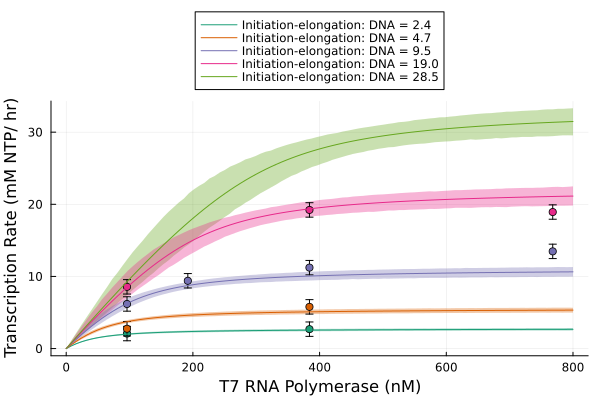

Initiation Limited Model: 2.88 percent relative uncertainty


nothing

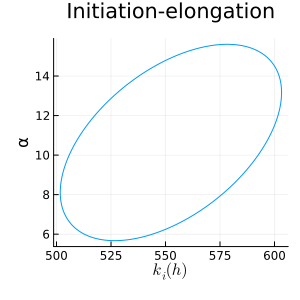

In [95]:
df = CSV.read("data/FlucIE_ProcessedData.csv",DataFrame)
Data = Matrix(df)
testmodelindex = 2#Index for model used for generating plot. 1  = initiation limited,  2 = initiation-elongation
extraDNA = [28.5]#For adding extra DNA lines to plot
npoints = 1000#Number of multistart points used

###########You don't have to change anything below this line##################
DPinputs = Data[:,1:2]
experimentaldata = Data[:,3]
experimentalnoise = ones(11)#Data[:,4]

nDNA = length(unique(DPinputs[:,1])) + length(extraDNA)
DPinputs[:,1] .= DPinputs[:,1].* 1e9 ./(N_all*607.4)#DNA concentration conversion
DPinputs[:,2] .= DPinputs[:,2].*16#T7 concentration conversion

truemodelindex = 1
truemodel = modellist[truemodelindex]
truemodelname = modelnamelist[truemodelindex]
testmodel = modellist[testmodelindex]
testmodelname = modelnamelist[testmodelindex]

normalizexaxis = false
normalizeyaxis = false

plt = plot()
plotexperimentaldata!(plt,DPinputs,experimentaldata,extraDNA = extraDNA)
(p_null,p_thintrue,truecov) = multistartoptimizeparams(truemodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints)
(p_estimated,p_thintest,testcov) = multistartoptimizeparams(testmodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints)
plotmodelprediction!(plt,testmodel,p_thintest,testcov,p_base,DPinputs,normalizexaxis = normalizexaxis,normalizeyaxis =normalizeyaxis, modelname = testmodelname, maximumT7 = 800, color =  :Dark2_5, showuncertainty = true, extraDNA = extraDNA)
plot!(legend = :outertop)
display(plt)
pltelps1 = plotparametricellipse(p_thintrue,truecov,title = truemodelname)
display(pltelps1)
pltelps2 = plotparametricellipse(p_thintest,testcov,title = testmodelname)
display(pltelps2)

<h1>MBDOE for Fluc<h1>

In [96]:
#Performing optimization for MBDOE
nexperiments = 1
initguess = DPinputs[1:nexperiments,:][:]
(minf,minx,ret) = multistartMBDOEoptimization(testmodel,p_thintest, initguess, p_base,priormatrix = inv(testcov),npoints = 1000)
println(minf)
mbdoeDP = reshape(minx,(2,nexperiments))

got 178.11878528103372 at [28.5, 212.73357067865757] (returned FTOL_REACHED)
178.11878528103372


2×1 Matrix{Float64}:
  28.5
 212.73357067865757